In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# # Step 2: Load Dataset
# vidgen_df=pd.read_csv(r"E:\Cyberbullying\dataset\Dynamically Generated Hate Dataset v0.2.2.csv")  # Replace with actual path


In [3]:
# vidgen_df = vidgen_df[['text', '']]  # Keep only relevant columns

# label_map = {'nothate': 0, 'hate': 1}
# vidgen_df['label'] = vidgen_df['label'].map(label_map)
# print(vidgen_df['label'].value_counts())  # Check class balance


In [2]:
df= pd.read_csv(r'E:\Cyberbullying\dataset\11\combined_dataset.csv')

In [22]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # remove links
    text = re.sub(r'@\w+|#\w+', '', text)                # remove mentions/hashtags
    text = re.sub(r'[^a-z\s]', '', text)                 # remove numbers, punctuations
    return text

df['clean_tweet'] = df['text'].apply(clean_text)
def load_mhs_dataset(file_path):
    df = pd.read_csv(file_path)
    df = df[['text', 'hatespeech']].rename(columns={'text': 'text', 'hatespeech': 'label'})
    df['label'] = df['label'].map(lambda x: 1 if x in [1, 2] else 0)
    df['text'] = df['text'].apply(clean_text)

    return df

In [ ]:
# df=df[["text","hatespeech"]].rename(columns={"text": "text", "hatespeech": "label"})
# df["label"] = df["label"].map(lambda x: 1 if x in [1, 2] else 0)


KeyError: "['hatespeech'] not in index"

In [3]:
df['text'].drop_duplicates(inplace=True)

In [4]:
df.label.value_counts()  # Check class balance

label
1    118807
0    118778
Name: count, dtype: int64

In [ ]:
# # Step 3: Preprocess Text
# def clean_text(text):
#     text = text.lower()
#     text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # remove links
#     text = re.sub(r'@\w+|#\w+', '', text)                # remove mentions/hashtags
#     text = re.sub(r'[^a-z\s]', '', text)                 # remove numbers, punctuations
#     return text

# df['clean_tweet'] = df['text'].apply(clean_text)


In [5]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.array([0, 1])
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=df["label"])
# Output as a dictionary
class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)

{np.int64(0): np.float64(1.0001220764788092), np.int64(1): np.float64(0.9998779533192489)}


In [6]:
# Step 4: TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['text']).toarray()
y = df['label'].values


In [7]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
# Step 6: Train Logistic Regression
class_weight_dict = {0: 0.8407, 1: 1.2339}

model = LogisticRegression(max_iter=1000,class_weight=class_weight_dict)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{0: 0.8407, 1: 1.2339}"
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
# Step 7: Evaluation
y_pred = model.predict(X_test)
print("Classification Report of vidgen_df:\n", classification_report(y_test, y_pred))

Classification Report of vidgen_df:
               precision    recall  f1-score   support

           0       0.84      0.83      0.83     16125
           1       0.75      0.76      0.76     10986

    accuracy                           0.80     27111
   macro avg       0.80      0.80      0.80     27111
weighted avg       0.80      0.80      0.80     27111



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


Accuracy:  0.8037
Precision: 0.7542
Recall:    0.7647
F1-Score:  0.7594


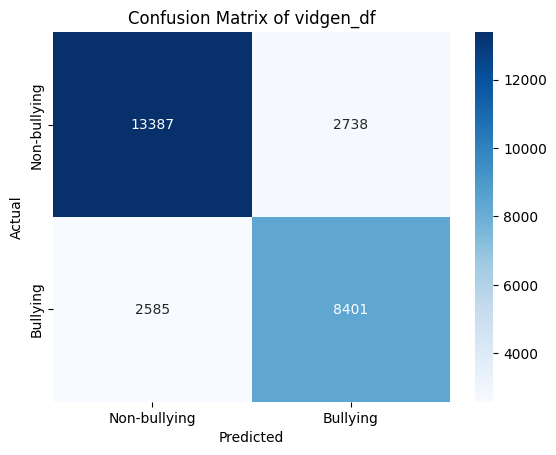

In [ ]:


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-bullying', 'Bullying'], yticklabels=['Non-bullying', 'Bullying'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of vidgen_df')
plt.show()


In [ ]:
davidson_df = pd.read_csv(r"E:\Cyberbullying\dataset\davidson.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'E:\\Cyberbullying\\dataset\\davidson.csv'

In [ ]:
davidson_df

In [ ]:
davidson_df['clean_tweet'] = davidson_df['tweet'].apply(clean_text)



In [ ]:
# Convert to binary: 0 or 1 = bullying, 2 = non-bullying
davidson_df['label'] = davidson_df['class'].apply(lambda x: 0 if x == 2 else 1)
davidson_df.drop(columns=['class'], inplace=True)

print(davidson_df['label'].value_counts())  # Check class balance

In [ ]:
# Step 4: TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(davidson_df['clean_tweet']).toarray()
y = davidson_df['label'].values


In [ ]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
# Step 6: Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


In [ ]:
# Step 7: Evaluation
y_pred = model.predict(X_test)
print("Classification Report of vidgen_df:\n", classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


In [ ]:


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-bullying', 'Bullying'], yticklabels=['Non-bullying', 'Bullying'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of vidgen_df')
plt.show()
